## Post-merger tail analysis with Bayesian

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.patches as mpatches
matplotlib.rcParams['mathtext.fontset'] ='stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral' 
matplotlib.rcParams['axes.linewidth'] = 1 #set the value globally
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams['font.size'] = '18'
plt.rc('text', usetex=True)

In [2]:
import sys
# provide a path for the gwtails package
PATH_TO_GWTAILS = "/Users/tousifislam/Research/projects/stupid/gwtails/"
sys.path.append(PATH_TO_GWTAILS)
import gwtails
from gwtails import PostMergerAmplitudeFit

lal.MSUN_SI != Msun


/Users/tousifislam/miniforge3/envs/kitp-py310/lib/python3.10/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [3]:
# import data file
# this is for a merging binary with 
# mass ratio q=1000, eccentricity e=0.9 and spin a=0.0
file = 'hm02_ecc_p09_e09_a00_q_1000.dat'

.......... Data read. Shape: (11, 11500)
..... time and strain/psi4 data is loaded
..... waveform mass-scale changed from m1 to M
..... strain/psi4 is cast onto a common time grid


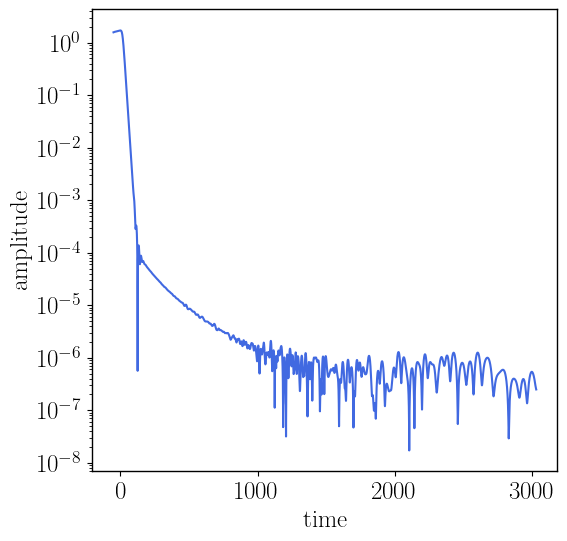

In [4]:
# pass it too gwtails without doing anything
# we will check the raw data first
rd = PostMergerAmplitudeFit(filename=file)

# and we are done
rd.plot_interpolated_amplitude()

In [5]:
# now pass it again to gwtails with fit options
rd = PostMergerAmplitudeFit(filename=file, 
                            throw_junk_until_indx=1100, # initial indices to remove before analyzing post-merger data
                            qnm_fit_window=[20,70], # time window to fit qnm
                            tail_fit_window=[200,1000],  # time window to fit tails
                            crossterm_fit_window=[30,400]) # time window to fit the crossterms

.......... Data read. Shape: (11, 11500)
..... time and strain/psi4 data is loaded
..... waveform mass-scale changed from m1 to M
..... junk data is removed from the start
..... strain/psi4 is cast onto a common time grid
..... fitting the tails with a decaying power law
..... fitting QNM with the 220 mode
..... fitting oscillatory intermediate part


In [6]:
# print interesting fit params
rd._print_all_fits()

Atail : 3.616772012e+05
c     : 2.816224620e+02
n     : 3.671228681e+00
Aqnm  : 5.773862018
tau   : 12.037748089
phi_tail : 7.757546169
omega    : 0.752826372


..... Fitting tail data with the function : Atail * (t + ctail)**ptail
..... Using data-driven initial guess
.......... Initial guess: log10_Atail=5.069, ctail=50.000, ptail=-5.000
..... Running MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 495.22it/s]


..... Bayesian Results:
.......... log10_Atail = 5.645 +/- 0.044
.......... Atail = 4.412e+05 +/- 4.524e+04
.......... ctail = 286.169 +/- 2.651
.......... ptail = -3.698 +/- 0.013
.......... log_likelihood = -4253.15 +/- 1.07
..... Done!


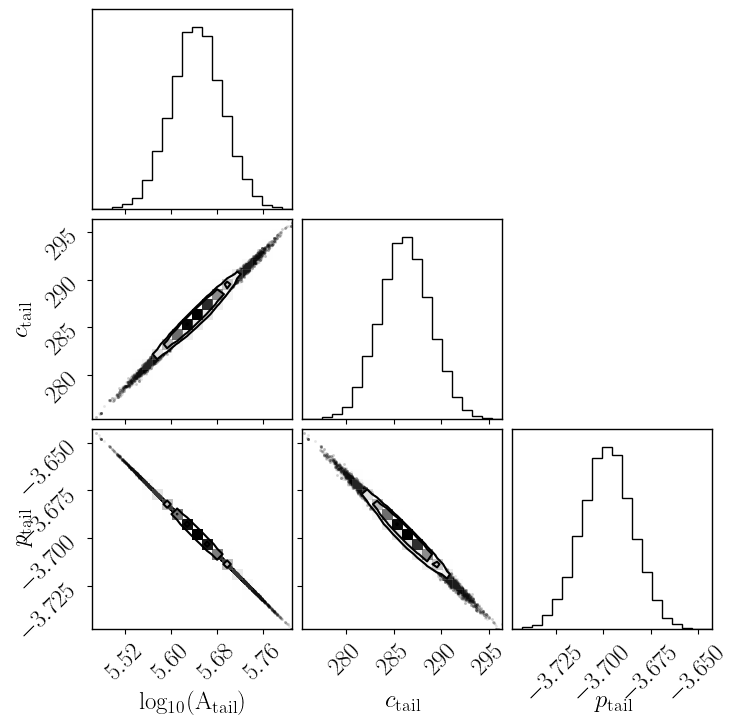

In [7]:
# Create fit instance
fitter = gwtails.TailFitMCMC(t=rd.t_interp, # post-merger time
                             A=abs(rd.h_interp), # post-merger amplitue
                             t_tail_window=[200, 800], 
                             lsq_params=None, # no initial guess
                             log_Atail_range=(0, 20), 
                             ctail_range=(0, 2500), 
                             ptail_range=(-15, -1),
                             fixed_params=None,
                             percentage_err_in_data=2.5)

# Perform fitting
samples, percentiles, log_likelihood = fitter.fit(n_walkers=32, n_steps=2000, burn_in=500)

# quick corner plot
fitter.plot_corner();